## 📝 Instrucciones

**Sistema de clasificación de imágenes**

El conjunto de datos se compone de fotos de perros y gatos proporcionadas como un subconjunto de fotos de uno mucho más grande de 3 millones de fotos anotadas manualmente. Estos datos se obtuvieron a través de una colaboración entre Petfinder.com y Microsoft.

El conjunto de datos se usó originalmente como un CAPTCHA, es decir, una tarea que se cree que un humano encuentra trivial, pero que una máquina no puede resolver, que se usa en sitios web para distinguir entre usuarios humanos y bots. La tarea se denominó "Asirra". Cuando se presentó "Asirra", se mencionó "que los estudios de usuarios indican que los humanos pueden resolverlo el 99,6% de las veces en menos de 30 segundos". A menos que se produzca un gran avance en la visión artificial, esperamos que los ordenadores no tengan más de 1/54.000 posibilidades de resolverlo.

En el momento en que se publicó la competencia, el resultado de última generación se logró con un SVM y se describió en un artículo de 2007 con el título "Ataques de Machine Learning contra el CAPTCHA de Asirra" (PDF) que logró una precisión de clasificación del 80%. Fue este documento el que demostró que la tarea ya no era una tarea adecuada para un CAPTCHA poco después de que se propusiera la tarea.

## Paso 1: Carga del conjunto de datos

El conjunto de datos se encuentra en este link. Descarga la carpeta y descomprime los archivos. Ahora tendrás una carpeta con el dataset y una carpeta llamada train que contiene más de 25.000 archivos de imagen (formato .jpg) de perros y gatos. Las fotos están etiquetadas por su nombre de archivo, con la palabra dog o cat.

In [ ]:
import os
import copy

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchsummary import summary
from sklearn.metrics import classification_report, confusion_matrix

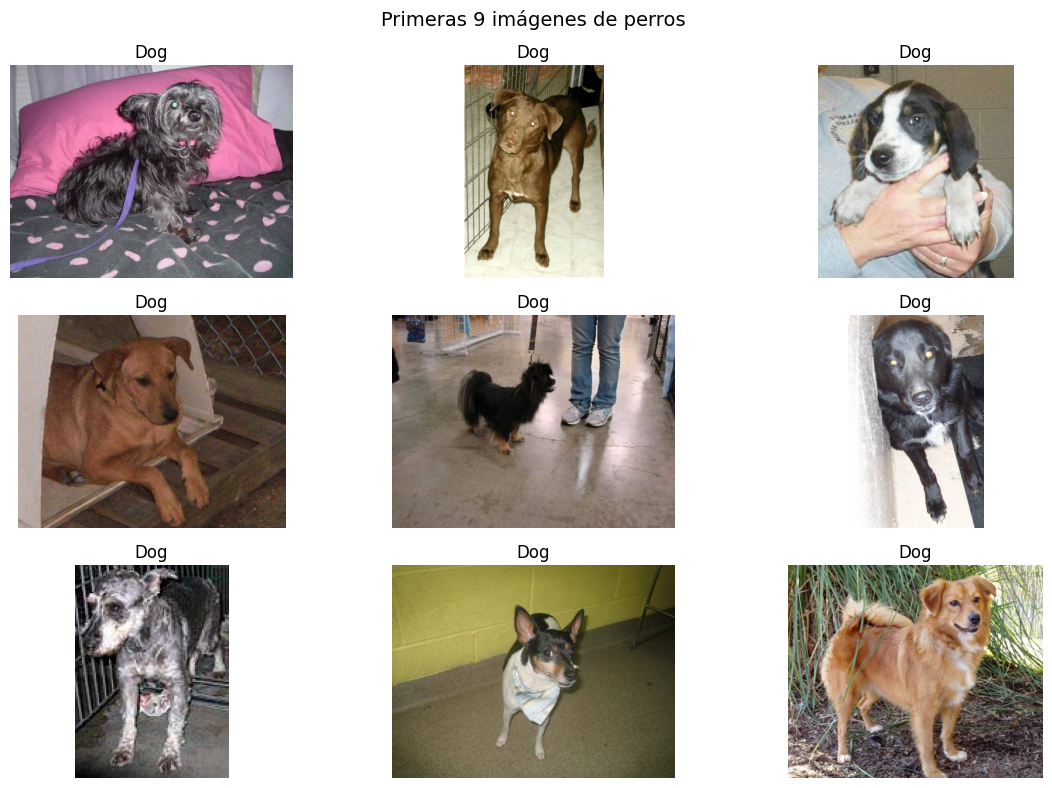

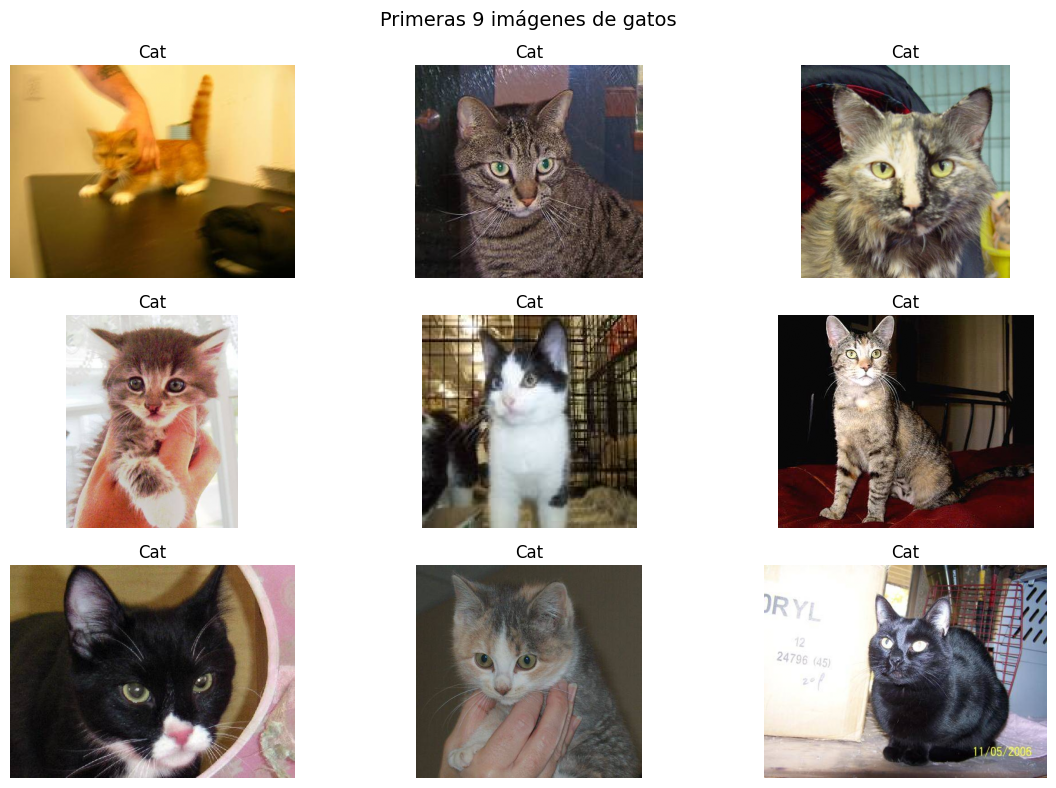

In [2]:
data_dir = os.path.join("..", "data", "raw", "dogs-vs-cats", "train")

# Filtrar imágenes por nombre de archivo
all_files = os.listdir(data_dir)
dog_image_files = sorted([f for f in all_files if f.startswith("dog")])
cat_image_files = sorted([f for f in all_files if f.startswith("cat")])

# Función auxiliar para cargar imágenes
def load_images(file_list, folder, n=9):
    images = []
    for i in range(n):
        img_path = os.path.join(folder, file_list[i])
        img = Image.open(img_path).convert("RGB")
        img_array = np.array(img) / 255.0
        images.append(img_array)
    return images

# Cargar primeras 9 de cada clase
dog_images = load_images(dog_image_files, data_dir)
cat_images = load_images(cat_image_files, data_dir)

# Mostrar perros
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(dog_images[i])
    plt.title('Dog')
    plt.axis('off')
plt.suptitle('Primeras 9 imágenes de perros', fontsize=14)
plt.tight_layout()
plt.show()

# Mostrar gatos
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(cat_images[i])
    plt.title('Cat')
    plt.axis('off')
plt.suptitle('Primeras 9 imágenes de gatos', fontsize=14)
plt.tight_layout()
plt.show()

## Paso 2: Visualiza la información de entrada

El primer paso cuando nos enfrentamos a un problema de clasificación de imágenes es obtener toda la información posible a través de ellas. Por lo tanto, carga e imprime las primeras nueve fotos de perros en una sola figura. Repite lo mismo para los gatos. Puedes ver que las fotos son a color y tienen diferentes formas y tamaños.

Esta variedad de tamaños y formatos debe solucionarse antes de entrenar el modelo. Asegúrate de que todas tengan un tamaño fijo de 200x200 píxeles.

Como podrás ver, son una gran cantidad de imágenes, asegúrate de seguir las siguientes normas:

>1. Si tienes más de 12 gigabytes de RAM, usa la API de procesamiento de imágenes de Keras para cargar las 25.000 fotos en el conjunto de datos de entrenamiento y remodelarlas a fotos cuadradas de 200×200 píxeles. La etiqueta también debe determinarse para cada foto en función de los nombres de archivo. Se debe guardar una tupla de fotos y etiquetas._

>2. Si no tienes más de 12 gigabytes de RAM, carga las imágenes progresivamente usando la clase Keras ImageDataGenerator y la función flow_from_directory(). Esto será más lento de ejecutar, pero se ejecutará en hardware de menor capacidad. Esta función prefiere que los datos se dividan en directorios train y test separados, y debajo de cada directorio para tener un subdirectorio para cada clase.
    
Una vez tengas todas las imágenes procesadas, crea un objeto ImageDataGenerator para datos de entrenamiento y prueba. Luego pasa la carpeta que tiene datos de entrenamiento al objeto trdata y, de manera similar, pasa la carpeta que tiene datos de prueba al objeto tsdata. De esta forma, se etiquetarán las imágenes automáticamente y estará todo listo para entrar a la red.

### Adaptación del pipeline de datos: Keras → PyTorch

El enunciado plantea dos opciones según la RAM disponible: cargar todo con la API de Keras
o usar `ImageDataGenerator` con `flow_from_directory`. Ambas se descartaron por las siguientes razones:

- **Keras + array numpy:** intentado inicialmente, produjo `MemoryError` al intentar alojar
  25k imágenes como `float64` (~22 GB) y luego como `float32` (~11 GB).
- **`ImageDataGenerator`:** requiere reorganizar las imágenes en subdirectorios por clase,
  y la lectura imagen a imagen en cada batch mantenía la GPU al 14% de uso.

**Solución adoptada en PyTorch:**
Las 25k imágenes se preprocesan una sola vez — redimensionado, normalización y conversión
a tensor — y se guardan en un único archivo `.pt` (~11 GB en `float32`). En ejecuciones
posteriores se carga directamente desde disco. Un `TensorDataset` personalizado sirve los
datos desde RAM al DataLoader sin ninguna decodificación de imagen, llevando la GPU al 97%
de utilización durante el entrenamiento.

In [3]:
IMG_SIZE = (200, 200)
raw_dir   = os.path.join("..", "data", "raw", "dogs-vs-cats", "train")
pt_path   = os.path.join("..", "data", "processed", "dogs_vs_cats.pt")
os.makedirs(os.path.dirname(pt_path), exist_ok=True)

if not os.path.exists(pt_path):
    print("Preprocesando imágenes por primera vez...")
    transform = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    all_files = sorted([f for f in os.listdir(raw_dir) if f.endswith(".jpg")])
    photos_list, labels_list = [], []
    for i, fname in enumerate(all_files):
        img = Image.open(os.path.join(raw_dir, fname)).convert("RGB")
        photos_list.append(transform(img))
        labels_list.append(1 if fname.startswith("dog") else 0)
        if (i + 1) % 1000 == 0:
            print(f"  {i+1}/25000...")
    photos_tensor = torch.stack(photos_list)
    labels_tensor = torch.tensor(labels_list, dtype=torch.long)
    torch.save({'photos': photos_tensor, 'labels': labels_tensor}, pt_path)
    print(f"✅ Guardado en {pt_path}")
else:
    print("Cargando tensor preprocesado...")
    data = torch.load(pt_path)
    photos_tensor = data['photos']
    labels_tensor = data['labels']
    print(f"✅ Cargado")

print(f"Shape: {photos_tensor.shape} | Dtype: {photos_tensor.dtype}")

# Dataset desde tensor (lectura directa en memoria)
class TensorDataset(Dataset):
    def __init__(self, photos, labels):
        self.photos = photos
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.photos[idx], self.labels[idx]

full_dataset = TensorDataset(photos_tensor, labels_tensor)
print(f"Total imágenes: {len(full_dataset)}")

Cargando tensor preprocesado...
✅ Cargado
Shape: torch.Size([25000, 3, 200, 200]) | Dtype: torch.float32
Total imágenes: 25000


Split 80/20 con semilla fija para reproducibilidad. `num_workers=0` porque los datos ya están
en RAM — el multiproceso solo añadiría overhead. `pin_memory=True` acelera la transferencia
de tensores a la GPU.

In [ ]:
BATCH_SIZE = 32

train_size = int(0.8 * len(full_dataset))
test_size  = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(
    full_dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

trdata = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
tsdata = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")
print("✅ Generadores listos")

Train: 20000 | Test: 5000
✅ Generadores listos


## Paso 3: Construye una RNA

Cualquier clasificador que se ajuste a este problema tendrá que ser robusto porque algunas imágenes muestran al gato o al perro en una esquina o tal vez a 2 gatos o perros en la misma foto. Si has podido investigar algunas de las implementaciones de los ganadores de otras competiciones también relacionadas con imágenes, verás que VGG16 es una arquitectura de CNN utilizada para ganar la competencia de Kaggle ILSVR (Imagenet) en 2014. Se considera una de las arquitecturas de modelos de visión con mejores resultados hasta la fecha.

**Utiliza la siguiente arquitectura de prueba:**

    model = Sequential()
    model.add(Conv2D(input_shape = (224,224,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))
    model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
    model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
    model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
    model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
    model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
    model.add(Flatten())
    model.add(Dense(units = 4096,activation = "relu"))
    model.add(Dense(units = 4096,activation = "relu"))
    model.add(Dense(units = 2, activation = "softmax"))

El código anterior aplica convoluciones a los datos (capas Conv2D y MaxPool2D) y después aplica capas densas (capas Dense) para el procesamiento de los valores numéricos obtenidos tras las convoluciones.

A continuación añade los elementos restantes para conformar el modelo, entrénalo y mide su rendimiento.

### Modelo VGG16-style desde cero (referencia)
Este fue el primer intento de arquitectura, construido desde cero sin pesos preentrenados.
No convergió — la loss se quedó fija en 0.6932 (ln(2)), equivalente a predicción aleatoria.
La causa fue la inicialización aleatoria de 138M parámetros sin suficientes datos ni épocas.
Se descartó en favor del modelo preentrenado con pesos de ImageNet (ver celda siguiente).

In [ ]:
# Modificación: input (200,200,3) → tras 5 MaxPool de stride 2: 200/32 = 6 → Linear(512*6*6)
class VGG16Style(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Bloque 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Bloque 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Bloque 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Bloque 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 6 * 6, 4096), nn.ReLU(inplace=True),
            nn.Linear(4096, 4096), nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device} — {torch.cuda.get_device_name(0)}")

model = VGG16Style(num_classes=2).to(device)

# Equivalente a model.summary()
summary(model, input_size=(3, 200, 200))

Dispositivo: cuda — NVIDIA GeForce RTX 5070 Laptop GPU
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 200, 200]           1,792
              ReLU-2         [-1, 64, 200, 200]               0
            Conv2d-3         [-1, 64, 200, 200]          36,928
              ReLU-4         [-1, 64, 200, 200]               0
         MaxPool2d-5         [-1, 64, 100, 100]               0
            Conv2d-6        [-1, 128, 100, 100]          73,856
              ReLU-7        [-1, 128, 100, 100]               0
            Conv2d-8        [-1, 128, 100, 100]         147,584
              ReLU-9        [-1, 128, 100, 100]               0
        MaxPool2d-10          [-1, 128, 50, 50]               0
           Conv2d-11          [-1, 256, 50, 50]         295,168
             ReLU-12          [-1, 256, 50, 50]               0
           Conv2d-13          [-1, 256, 50, 50] 

### Modelo VGG16 preentrenado con Transfer Learning (modelo final)

Para resolver los problemas del modelo desde cero se aplicaron tres modificaciones:

1. **Pesos preentrenados de ImageNet** — en lugar de inicialización aleatoria, se cargan pesos
   entrenados sobre 1.2M imágenes de 1000 clases. La red ya reconoce bordes, texturas y formas,
   lo que permite converger desde la primera época.

2. **Capas convolucionales congeladas** — `features` completo (138M parámetros) se congela con
   `requires_grad = False`. Solo se entrenan las capas densas del clasificador (~16M parámetros),
   lo que estabiliza el gradiente y reduce el tiempo por época de ~7 min a ~2 min.

3. **Sustitución de la capa de salida** — `classifier[6]` se reemplaza de `Linear(4096, 1000)`
   (ImageNet) a `Linear(4096, 2)` (cat/dog), adaptando la red a la clasificación binaria.

**Resultado:** 98.24% val_accuracy en 8 épocas con early stopping.

In [ ]:
base_model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Congelar todas las capas convolucionales
for param in base_model.features.parameters():
    param.requires_grad = False

# Reemplazar solo la última capa
base_model.classifier[6] = nn.Linear(4096, 2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device} — {torch.cuda.get_device_name(0)}")

model = base_model.to(device)
summary(model, input_size=(3, 200, 200))

Dispositivo: cuda — NVIDIA GeForce RTX 5070 Laptop GPU
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 200, 200]           1,792
              ReLU-2         [-1, 64, 200, 200]               0
            Conv2d-3         [-1, 64, 200, 200]          36,928
              ReLU-4         [-1, 64, 200, 200]               0
         MaxPool2d-5         [-1, 64, 100, 100]               0
            Conv2d-6        [-1, 128, 100, 100]          73,856
              ReLU-7        [-1, 128, 100, 100]               0
            Conv2d-8        [-1, 128, 100, 100]         147,584
              ReLU-9        [-1, 128, 100, 100]               0
        MaxPool2d-10          [-1, 128, 50, 50]               0
           Conv2d-11          [-1, 256, 50, 50]         295,168
             ReLU-12          [-1, 256, 50, 50]               0
           Conv2d-13          [-1, 256, 50, 50] 

In [ ]:
EPOCHS    = 20
LR        = 1e-4  # corregido desde 1e-3
PATIENCE  = 3
MODEL_PATH = "../models/vgg16_pytorch_best.pth"
os.makedirs("../models", exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc     = 0.0
best_weights     = None
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    train_loss, train_correct = 0.0, 0
    for imgs, labels in trdata:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * imgs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    # --- Validation ---
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for imgs, labels in tsdata:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss    += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    t_loss = train_loss / len(train_dataset)
    t_acc  = train_correct / len(train_dataset)
    v_loss = val_loss / len(test_dataset)
    v_acc  = val_correct / len(test_dataset)

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

    # Checkpoint + Early Stopping
    if v_acc > best_val_acc:
        best_val_acc  = v_acc
        best_weights  = copy.deepcopy(model.state_dict())
        torch.save(best_weights, MODEL_PATH)
        print(f"  ✅ Mejor modelo guardado (val_acc={best_val_acc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  ⏳ Sin mejora ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("  🛑 Early stopping activado")
            break

model.load_state_dict(best_weights)
print(f"\nEntrenamiento completado. Mejor val_acc: {best_val_acc:.4f}")

Epoch 01/20 | Train Loss: 0.0717 Acc: 0.9739 | Val Loss: 0.0560 Acc: 0.9784
  ✅ Mejor modelo guardado (val_acc=0.9784)
Epoch 02/20 | Train Loss: 0.0383 Acc: 0.9871 | Val Loss: 0.0649 Acc: 0.9798
  ✅ Mejor modelo guardado (val_acc=0.9798)
Epoch 03/20 | Train Loss: 0.0234 Acc: 0.9923 | Val Loss: 0.0763 Acc: 0.9804
  ✅ Mejor modelo guardado (val_acc=0.9804)
Epoch 04/20 | Train Loss: 0.0249 Acc: 0.9914 | Val Loss: 0.0730 Acc: 0.9818
  ✅ Mejor modelo guardado (val_acc=0.9818)
Epoch 05/20 | Train Loss: 0.0117 Acc: 0.9962 | Val Loss: 0.0881 Acc: 0.9824
  ✅ Mejor modelo guardado (val_acc=0.9824)
Epoch 06/20 | Train Loss: 0.0110 Acc: 0.9968 | Val Loss: 0.1075 Acc: 0.9806
  ⏳ Sin mejora (1/3)
Epoch 07/20 | Train Loss: 0.0136 Acc: 0.9958 | Val Loss: 0.1245 Acc: 0.9808
  ⏳ Sin mejora (2/3)
Epoch 08/20 | Train Loss: 0.0222 Acc: 0.9943 | Val Loss: 0.1280 Acc: 0.9808
  ⏳ Sin mejora (3/3)
  🛑 Early stopping activado

Entrenamiento completado. Mejor val_acc: 0.9824


: 

## Paso 4: Optimiza el modelo anterior

Importa el método ModelCheckpoint y EarlyStopping de Keras. Crea un objeto de ambos y pásalo como funciones callback a fit_generator.

Carga el mejor modelo de los anteriores y utiliza el conjunto de test para hacer predicciones.


Aclaración: En PyTorch no existen callbacks como en Keras, por lo que ModelCheckpoint y EarlyStopping
se implementaron manualmente dentro del loop de entrenamiento:

- **Checkpoint:** en cada época se compara `val_acc` con el mejor valor registrado. Si mejora,
  se guardan los pesos con `torch.save`.
- **Early Stopping:** un contador `patience_counter` incrementa cuando no hay mejora. Si llega
  a `patience=3` épocas consecutivas sin mejora, el entrenamiento se detiene.

A continuación se carga el mejor modelo guardado y se evalúa sobre el conjunto de test
generando un reporte de clasificación y una matriz de confusión.

              precision    recall  f1-score   support

         Cat       0.98      0.99      0.98      2513
         Dog       0.99      0.98      0.98      2487

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



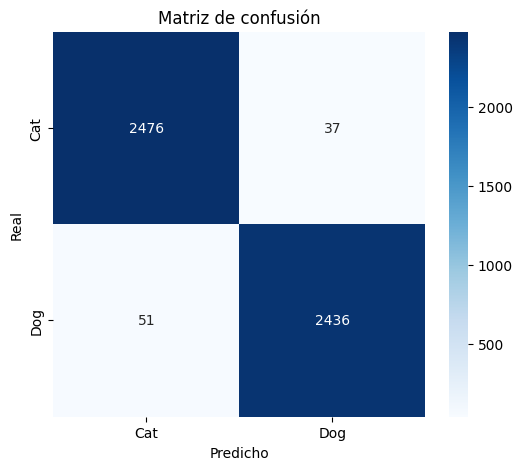

In [ ]:
# Cargar mejor modelo
MODEL_PATH = "../models/vgg16_pytorch_best.pth"
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tsdata:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=['Cat', 'Dog']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Matriz de confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

## Paso 5: Guarda el modelo

Almacena el modelo en la carpeta correspondiente.

In [10]:
MODEL_PATH = "../models/cats_vs_dogs/vgg16_pytorch_best.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"✅ Modelo guardado en: {MODEL_PATH}")

✅ Modelo guardado en: ../models/cats_vs_dogs/vgg16_pytorch_best.pth
